# Phase 2 v6 — Municipal, Region, Island Analysis + Scenario Forecasting

This notebook extends Phase 2 to support:
- descriptive analysis tables and event-study style summaries
- a **chronological 80/20 train–test split** with an internal validation year
- model comparison across linear and nonlinear methods
- interpretability that follows the **best-performing fitted model**
- lead–lag sensitivity analysis
- municipal, regional, and island-level scenario forecasting


In [1]:
import os, json, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import re

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("phase2_outputs_v6")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILENAMES = [
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
]

# Search a few sensible locations first, then fall back to a small recursive search.
search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    OUTPUT_DIR.parent,
]

candidate_paths = []
for root in search_roots:
    for name in DATA_FILENAMES:
        candidate_paths.append(root / name)

for root in search_roots:
    if root.exists():
        for name in DATA_FILENAMES:
            candidate_paths.extend(root.rglob(name))

# de-duplicate while preserving order
seen = set()
candidate_paths = [p for p in candidate_paths if not (str(p.resolve()) in seen or seen.add(str(p.resolve())))]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find the processed Puerto Rico panel CSV. "
        "Expected one of: "
        f"{DATA_FILENAMES}. "
        "Place the CSV in the notebook folder, its parent folder, or update DATA_FILENAMES/search_roots."
    )

df = pd.read_csv(data_path)
print("Loaded:", data_path.resolve())
print("Shape:", df.shape)


def save_csv(df_obj, filename):
    path = OUTPUT_DIR / filename
    df_obj.to_csv(path, index=False)
    print(f"Saved: {path.resolve()}")
    return path

def save_json(obj, filename):
    path = OUTPUT_DIR / filename
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"Saved: {path.resolve()}")
    return path

saved_files = []

Loaded: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/processed_puerto_rico_data_rebuild.csv
Shape: (1170, 160)


In [2]:

region_map = {
    # Metro
    "San Juan": "Metro", "Bayamón": "Metro", "Carolina": "Metro", "Cataño": "Metro",
    "Guaynabo": "Metro", "Toa Alta": "Metro", "Toa Baja": "Metro", "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North", "Barceloneta": "North", "Camuy": "North", "Dorado": "North",
    "Florida": "North", "Hatillo": "North", "Manatí": "North", "Quebradillas": "North",
    "Vega Alta": "North", "Vega Baja": "North",

    # South
    "Arroyo": "South", "Coamo": "South", "Guayama": "South", "Guayanilla": "South",
    "Juana Díaz": "South", "Patillas": "South", "Peñuelas": "South", "Ponce": "South",
    "Salinas": "South", "Santa Isabel": "South", "Villalba": "South", "Yauco": "South",

    # West
    "Aguada": "West", "Aguadilla": "West", "Añasco": "West", "Cabo Rojo": "West",
    "Guánica": "West", "Hormigueros": "West", "Isabela": "West", "Lajas": "West",
    "Las Marías": "West", "Maricao": "West", "Mayagüez": "West", "Moca": "West",
    "Rincón": "West", "Sabana Grande": "West", "San Germán": "West", "San Sebastián": "West",

    # East
    "Canóvanas": "East", "Ceiba": "East", "Fajardo": "East", "Humacao": "East",
    "Juncos": "East", "Las Piedras": "East", "Loíza": "East", "Luquillo": "East",
    "Maunabo": "East", "Naguabo": "East", "Río Grande": "East", "San Lorenzo": "East",
    "Yabucoa": "East", "Caguas": "East", "Gurabo": "East", "Culebra": "East", "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains", "Aguas Buenas": "Central Mountains", "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains", "Cayey": "Central Mountains", "Ciales": "Central Mountains",
    "Cidra": "Central Mountains", "Comerío": "Central Mountains", "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains", "Lares": "Central Mountains", "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains", "Orocovis": "Central Mountains", "Utuado": "Central Mountains",
}

df["region"] = df["municipio"].map(region_map).fillna("Unassigned")
print(df["region"].value_counts(dropna=False))


region
East                 255
West                 240
Central Mountains    225
South                180
North                150
Metro                120
Name: count, dtype: int64


In [3]:

def first_existing(candidates, frame=df):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

col_population = first_existing(["total_population", "population"])
col_target = first_existing(["target_pop_change_3y_avg", "target_pop_change_2y_avg", "target_pop_change_1y"])
col_svi = first_existing(["svi_pca_1", "baseline_svi_pca_1", "baseline_vulnerability_index", "vulnerability_index"])
col_wind = first_existing(["wind_3yr_sum", "lag_wind_exposure_score_100km", "max_wind_knots"])
col_seis = first_existing(["seismic_3yr_sum", "lag_seismic_exposure_score_50km", "max_seismic_mag"])
col_hurr_x_svi = first_existing(["wind_3yr_x_svi", "hurricane_x_svi"])
col_quake_x_svi = first_existing(["seismic_3yr_x_svi", "earthquake_x_svi"])
col_income_growth = first_existing(["income_growth", "income_growth_3yr_avg"])
col_est_growth = first_existing(["establishment_growth", "lag_establishment_growth", "establishment_count"])
col_crime = first_existing(["lag_total_crime_rate", "total_crime_rate"])

resolved = {
    "population": col_population,
    "target": col_target,
    "svi": col_svi,
    "wind": col_wind,
    "seismic": col_seis,
    "wind_x_svi": col_hurr_x_svi,
    "seis_x_svi": col_quake_x_svi,
    "income_growth": col_income_growth,
    "est_growth": col_est_growth,
    "crime": col_crime,
}
resolved


{'population': 'total_population',
 'target': 'target_pop_change_3y_avg',
 'svi': 'svi_pca_1',
 'wind': 'wind_3yr_sum',
 'seismic': 'seismic_3yr_sum',
 'wind_x_svi': 'wind_3yr_x_svi',
 'seis_x_svi': 'seismic_3yr_x_svi',
 'income_growth': 'income_growth',
 'est_growth': 'establishment_growth',
 'crime': 'lag_total_crime_rate'}

## Descriptive analysis tables

These outputs support the narrative:

- Here is population change, vulnerability, hurricanes, and earthquakes since 2010
- At municipal, regional, and island levels
- Before and after shocks


In [4]:

metric_cols = [c for c in [
    resolved["population"], resolved["target"], resolved["svi"], resolved["wind"], resolved["seismic"],
    resolved["wind_x_svi"], resolved["seis_x_svi"], resolved["income_growth"], resolved["est_growth"], resolved["crime"]
] if c is not None]

municipal_latest = (
    df.sort_values(["municipio", "year"])
      .groupby("municipio", as_index=False)
      .tail(1)[["municipio", "region", "year"] + metric_cols]
      .sort_values(["region", "municipio"])
)

region_year = (
    df.groupby(["region", "year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)

island_year = (
    df.groupby(["year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)
island_year["region"] = "Puerto Rico"

saved_files.append(str(save_csv(municipal_latest, "municipal_latest_snapshot.csv")))
saved_files.append(str(save_csv(region_year, "region_year_summary.csv")))
saved_files.append(str(save_csv(island_year, "island_year_summary.csv")))

print("Saved descriptive summaries to", OUTPUT_DIR)
municipal_latest.head()


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/municipal_latest_snapshot.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/region_year_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/island_year_summary.csv
Saved descriptive summaries to phase2_outputs_v6


,municipio,region,year,total_population,target_pop_change_3y_avg,svi_pca_1,wind_3yr_sum,seismic_3yr_sum,wind_3yr_x_svi,seismic_3yr_x_svi,income_growth,establishment_growth,lag_total_crime_rate
14,Adjuntas,Central Mountains,2024,17960.0,NaN,NaN,4.973126,98287.824739,18.710486,369790.156448,9.391400,NaN,100.139082
59,Aguas Buenas,Central Mountains,2024,23614.0,NaN,NaN,2.961816,47341.651881,8.106970,129581.780127,7.419301,NaN,71.165439
74,Aibonito,Central Mountains,2024,24636.0,NaN,NaN,3.142504,56348.106850,8.820083,158152.554087,4.252832,NaN,77.204388
149,Barranquitas,Central Mountains,2024,29054.0,NaN,NaN,3.150477,58294.740677,13.025665,241019.941799,9.932738,NaN,96.605023
269,Cayey,Central Mountains,2024,40917.0,NaN,NaN,3.012615,51112.542988,6.629618,112479.228034,10.210463,NaN,109.141180


In [5]:

# Event-study style summaries: compare periods with stronger hazard burden
tmp = df.copy()

if resolved["svi"] is not None:
    tmp["svi_group"] = pd.qcut(tmp[resolved["svi"]].rank(method="first"), 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"])

event_summary = []
for hazard_name, hazard_col in [("hurricane", resolved["wind"]), ("earthquake", resolved["seismic"])]:
    if hazard_col is None or resolved["target"] is None:
        continue
    threshold = tmp[hazard_col].quantile(0.75)
    tmp[f"{hazard_name}_high"] = (tmp[hazard_col] >= threshold).astype(int)

    grp = (
        tmp.groupby([f"{hazard_name}_high", "region"], as_index=False)[[resolved["target"], resolved["svi"]]]
           .mean(numeric_only=True)
    )
    grp["hazard"] = hazard_name
    grp["threshold_used"] = threshold
    event_summary.append(grp)

    if "svi_group" in tmp.columns:
        grp2 = (
            tmp.groupby([f"{hazard_name}_high", "svi_group"], as_index=False)[[resolved["target"], resolved["svi"]]]
               .mean(numeric_only=True)
        )
        grp2["hazard"] = hazard_name
        grp2["threshold_used"] = threshold
        saved_files.append(str(save_csv(grp2, f"{hazard_name}_by_svi_group_summary.csv")))

event_summary_df = pd.concat(event_summary, ignore_index=True) if event_summary else pd.DataFrame()
saved_files.append(str(save_csv(event_summary_df, "event_study_region_summary.csv")))
event_summary_df.head(12)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/hurricane_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/earthquake_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/event_study_region_summary.csv


,hurricane_high,region,target_pop_change_3y_avg,svi_pca_1,hazard,threshold_used,earthquake_high
0,0.0,Central Mountains,-0.942186,1.093256,hurricane,7.046256,NaN
1,0.0,East,-1.342352,-0.095236,hurricane,7.046256,NaN
2,0.0,Metro,-1.249240,-2.155443,hurricane,7.046256,NaN
3,0.0,North,-0.777883,-0.021532,hurricane,7.046256,NaN
4,0.0,South,-1.467870,0.873182,hurricane,7.046256,NaN
5,0.0,West,-1.116644,0.448364,hurricane,7.046256,NaN
6,1.0,Central Mountains,-0.670669,0.463026,hurricane,7.046256,NaN
7,1.0,East,-1.275465,-0.161643,hurricane,7.046256,NaN
8,1.0,Metro,-1.065718,-2.838944,hurricane,7.046256,NaN
9,1.0,North,-0.849243,-0.620902,hurricane,7.046256,NaN


## Modeling setup

This section implements the **Phase 2 forecasting workflow** using a **chronological 80–20 split** so later years remain fully out-of-sample.

The notebook compares multiple candidate models on the same temporally ordered data:
- OLS as a simple linear baseline
- Ridge and Lasso as regularized linear models
- Random Forest, HistGradientBoosting, and Extra Trees as nonlinear tree-based alternatives

The goal is not just to maximize fit in-sample, but to identify the model that generalizes best to later years under a realistic forecast-style evaluation.

In [6]:

# 80–20 chronological split with an internal validation year inside the training block
model_df = df.copy()

target_col = resolved["target"]
if target_col is None:
    raise ValueError("No target column found.")

model_df = model_df.sort_values(["municipio", "year"]).reset_index(drop=True)

# -------------------------------------------------------------------
# Temporal feature engineering using ONLY past information within each
# municipality. These additions are designed to help both linear and
# nonlinear models generalize better under a chronological split.
# -------------------------------------------------------------------
lag_source_candidates = [
    resolved["target"],
    resolved["svi"],
    resolved["wind"],
    resolved["seismic"],
    resolved["income_growth"],
    resolved["est_growth"],
    resolved["crime"],
    resolved["population"],
]

lag_source_candidates = [c for c in lag_source_candidates if c is not None and c in model_df.columns]
grouped = model_df.groupby("municipio", group_keys=False)

for col in lag_source_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()
    # 1-year lag
    lag1 = f"{safe}_lag1"
    if lag1 not in model_df.columns:
        model_df[lag1] = grouped[col].shift(1)

    # 2-year lag
    lag2 = f"{safe}_lag2"
    if lag2 not in model_df.columns:
        model_df[lag2] = grouped[col].shift(2)

    # 3-year rolling mean based only on PRIOR years
    roll3 = f"{safe}_roll3_mean"
    if roll3 not in model_df.columns:
        model_df[roll3] = (
            grouped[col]
            .apply(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

    # year-over-year change based on prior period
    yoy = f"{safe}_yoy_change"
    if yoy not in model_df.columns:
        model_df[yoy] = grouped[col].diff(1)

# Conservative + temporally enriched feature set
base_feature_candidates = [
    "lag_pop_change_1",
    "lag_pop_change_2",
    resolved["population"],
    resolved["svi"],
    resolved["wind"],
    resolved["seismic"],
    resolved["wind_x_svi"],
    resolved["seis_x_svi"],
    resolved["income_growth"],
    resolved["est_growth"],
    resolved["crime"],
    "year",
]

generated_feature_candidates = []
for col in lag_source_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()
    generated_feature_candidates.extend([
        f"{safe}_lag1",
        f"{safe}_lag2",
        f"{safe}_roll3_mean",
        f"{safe}_yoy_change",
    ])

feature_candidates = base_feature_candidates + generated_feature_candidates
feature_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]
feature_cols = list(dict.fromkeys(feature_cols))  # preserve order, remove duplicates

# Add municipality fixed effects for panel structure
X = model_df[feature_cols + ["municipio", "region"]].copy()
y = model_df[target_col].copy()

# Keep rows with valid target and at least some non-missing numeric information
valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].copy()
model_df = model_df.loc[valid].copy()

# Remove features that are entirely missing after target restriction
usable_num_cols = [c for c in feature_cols if c in X.columns and X[c].notna().any()]
dropped_num_cols = [c for c in feature_cols if c not in usable_num_cols]
feature_cols = usable_num_cols
X = X[feature_cols + ["municipio", "region"]].copy()

print("Using features:", feature_cols)
if dropped_num_cols:
    print("Dropped all-missing engineered features:", dropped_num_cols)

# -------------------------------------------------------------------
# Chronological 80–20 split by the YEARS ACTUALLY AVAILABLE FOR THE TARGET.
# For target_pop_change_3y_avg, the latest raw panel years may not have
# valid target values, so the split must be based on model_df after
# dropping missing targets, not on the full raw panel.
# -------------------------------------------------------------------
model_df["year"] = pd.to_numeric(model_df["year"], errors="coerce")
available_years = sorted(int(y) for y in model_df["year"].dropna().unique().tolist())
print("Available target years:", available_years)

if len(available_years) < 5:
    raise ValueError(f"Not enough target years available for a chronological 80–20 split: {available_years}")

n_years = len(available_years)
n_test_years = max(1, round(n_years * 0.20))
# keep at least one validation year inside the training block
n_test_years = min(n_test_years, n_years - 2)

test_years = available_years[-n_test_years:]
outer_train_years = available_years[:-n_test_years]
val_year = outer_train_years[-1]
train_years = outer_train_years[:-1]

print("Pre-validation training block:", outer_train_years)
print("Final train years:", train_years)
print("Validation year:", val_year)
print("Test years:", test_years)

outer_train_mask = model_df["year"].isin(outer_train_years)
val_mask = model_df["year"] == val_year
train_mask = model_df["year"].isin(train_years)
test_mask = model_df["year"].isin(test_years)

if not outer_train_mask.any() or not train_mask.any() or not val_mask.any() or not test_mask.any():
    raise ValueError(
        "Chronological 80–20 split failed after restricting to target-eligible years. "
        f"Available years: {available_years}, train_years: {train_years}, val_year: {val_year}, test_years: {test_years}"
    )

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val, y_val = X.loc[val_mask].copy(), y.loc[val_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

num_cols = [c for c in feature_cols if c in X.columns]
cat_cols = ["municipio", "region"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), cat_cols),
    ]
)

pre_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), cat_cols),
    ]
)

# Backward-compatible alias used by later cells
pre = pre_tree

# Persist split metadata for downstream cells / saved outputs
split_metadata = {
    "available_target_years": available_years,
    "outer_train_years": outer_train_years,
    "validation_year": int(val_year),
    "test_years": test_years,
    "split_type": "chronological_80_20_on_target_eligible_years",
    "n_numeric_features": len(num_cols),
    "n_categorical_features": len(cat_cols),
    "dropped_all_missing_features": dropped_num_cols,
}
print(split_metadata)


Using features: ['lag_pop_change_1', 'lag_pop_change_2', 'total_population', 'svi_pca_1', 'wind_3yr_sum', 'seismic_3yr_sum', 'wind_3yr_x_svi', 'seismic_3yr_x_svi', 'income_growth', 'establishment_growth', 'lag_total_crime_rate', 'year', 'target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_lag2', 'target_pop_change_3y_avg_roll3_mean', 'target_pop_change_3y_avg_yoy_change', 'svi_pca_1_lag1', 'svi_pca_1_lag2', 'svi_pca_1_roll3_mean', 'svi_pca_1_yoy_change', 'wind_3yr_sum_lag1', 'wind_3yr_sum_lag2', 'wind_3yr_sum_roll3_mean', 'wind_3yr_sum_yoy_change', 'seismic_3yr_sum_lag1', 'seismic_3yr_sum_lag2', 'seismic_3yr_sum_roll3_mean', 'seismic_3yr_sum_yoy_change', 'income_growth_lag1', 'income_growth_lag2', 'income_growth_roll3_mean', 'income_growth_yoy_change', 'establishment_growth_lag1', 'establishment_growth_lag2', 'establishment_growth_roll3_mean', 'establishment_growth_yoy_change', 'lag_total_crime_rate_lag1', 'lag_total_crime_rate_lag2', 'lag_total_crime_rate_roll3_mean', 'lag_total

In [7]:

# Model comparison (chronological 80–20 split with internal validation year)
from sklearn.linear_model import LinearRegression, Lasso

# Sort the training block for time-series-aware inner CV tuning
cv_train_idx = X_train.assign(__year__=model_df.loc[train_mask, "year"].values).sort_values(["__year__", "municipio"]).index
X_train_cv = X_train.loc[cv_train_idx].copy()
y_train_cv = y_train.loc[cv_train_idx].copy()

n_cv_splits = min(3, max(2, len(sorted(set(train_years))) - 1))
tscv = TimeSeriesSplit(n_splits=n_cv_splits)

model_specs = {
    "ols": {
        "preprocessor": pre_linear,
        "estimator": LinearRegression(),
        "param_grid": {},
    },
    "ridge": {
        "preprocessor": pre_linear,
        "estimator": Ridge(random_state=42),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0],
        },
    },
    "lasso": {
        "preprocessor": pre_linear,
        "estimator": Lasso(max_iter=50000, random_state=42),
        "param_grid": {
            "model__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
        },
    },
    "random_forest": {
        "preprocessor": pre_tree,
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [300, 500],
            "model__max_depth": [4, 8, None],
            "model__min_samples_leaf": [2, 4, 8],
            "model__max_features": ["sqrt", 0.5],
        },
    },
    "hist_gradient_boosting": {
        "preprocessor": pre_tree,
        "estimator": HistGradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__learning_rate": [0.03, 0.05, 0.08],
            "model__max_depth": [3, 5, 7],
            "model__min_samples_leaf": [10, 20, 30],
            "model__max_iter": [200, 300],
            "model__l2_regularization": [0.0, 0.1, 1.0],
        },
    },
    "extra_trees": {
        "preprocessor": pre_tree,
        "estimator": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [500, 800],
            "model__max_depth": [6, 10, None],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", 0.5, 0.8],
        },
    },
}

results = []
pred_parts = []
fitted_models = {}
best_params_by_model = {}

for model_name, spec in model_specs.items():
    pipe = Pipeline([("pre", spec["preprocessor"]), ("model", spec["estimator"])])

    if spec["param_grid"]:
        search = GridSearchCV(
            estimator=pipe,
            param_grid=spec["param_grid"],
            scoring="r2",
            cv=tscv,
            n_jobs=-1,
            refit=True,
            error_score="raise",
        )
        search.fit(X_train_cv, y_train_cv)
        pipe = search.best_estimator_
        best_params_by_model[model_name] = search.best_params_
        cv_best_score = float(search.best_score_)
    else:
        pipe.fit(X_train_cv, y_train_cv)
        best_params_by_model[model_name] = {}
        cv_best_score = np.nan

    val_pred = pipe.predict(X_val)
    test_pred = pipe.predict(X_test)

    fitted_models[model_name] = pipe

    results.append({
        "model": model_name,
        "n_features": len(feature_cols),
        "features": ", ".join(feature_cols + cat_cols),
        "train_years": f"{min(train_years)}-{max(train_years)}",
        "validation_year": int(val_year),
        "test_years": f"{min(test_years)}-{max(test_years)}",
        "cv_best_r2": cv_best_score,
        "val_r2": float(r2_score(y_val, val_pred)),
        "test_r2": float(r2_score(y_test, test_pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_pred))),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
        "val_mae": float(mean_absolute_error(y_val, val_pred)),
        "test_mae": float(mean_absolute_error(y_test, test_pred)),
        "best_params": json.dumps(best_params_by_model[model_name], sort_keys=True),
        "split_type": split_metadata["split_type"],
    })

    pred_parts.append(pd.DataFrame({
        "model": model_name,
        "set": "validation",
        "municipio": X_val["municipio"].values,
        "region": X_val["region"].values,
        "year": model_df.loc[val_mask, "year"].values,
        target_col: y_val.values,
        "prediction": val_pred,
    }))
    pred_parts.append(pd.DataFrame({
        "model": model_name,
        "set": "test",
        "municipio": X_test["municipio"].values,
        "region": X_test["region"].values,
        "year": model_df.loc[test_mask, "year"].values,
        target_col: y_test.values,
        "prediction": test_pred,
    }))

results_df = (
    pd.DataFrame(results)
      .sort_values(["test_r2", "val_r2"], ascending=False)
      .reset_index(drop=True)
)

pred_df = pd.concat(pred_parts, ignore_index=True)

saved_files.append(str(save_csv(results_df, "phase2_v4_model_comparison.csv")))
saved_files.append(str(save_csv(pred_df, "phase2_v4_predictions_long.csv")))
saved_files.append(str(save_json(split_metadata, "phase2_v4_split_metadata.json")))
saved_files.append(str(save_json(best_params_by_model, "phase2_v4_model_best_params.json")))

display(results_df)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v4_model_comparison.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v4_predictions_long.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v4_split_metadata.json
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v4_model_best_params.json


,model,n_features,features,train_years,validation_year,test_years,cv_best_r2,val_r2,test_r2,val_rmse,test_rmse,val_mae,test_mae,best_params,split_type
0,lasso,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.644237,0.937335,0.867824,0.444125,0.546779,0.377442,0.487697,"{""model__alpha"": 0.05}",chronological_80_20_on_target_eligible_years
1,ridge,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.791117,0.833837,0.407923,0.723200,1.157245,0.622095,0.999390,"{""model__alpha"": 5.0}",chronological_80_20_on_target_eligible_years
2,hist_gradient_boosting,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.376406,0.668419,0.344389,1.021612,1.217753,0.753154,0.895169,"{""model__l2_regularization"": 1.0, ""model__lear...",chronological_80_20_on_target_eligible_years
3,random_forest,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.385842,0.358387,0.262727,1.421111,1.291369,1.141117,0.895012,"{""model__max_depth"": null, ""model__max_feature...",chronological_80_20_on_target_eligible_years
4,extra_trees,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,0.358534,0.196464,0.139975,1.590354,1.394736,1.307364,1.059990,"{""model__max_depth"": 10, ""model__max_features""...",chronological_80_20_on_target_eligible_years
5,ols,44,"lag_pop_change_1, lag_pop_change_2, total_popu...",2010-2018,2019,2020-2021,NaN,0.544573,-1.520056,1.197294,2.387489,1.005905,1.865997,{},chronological_80_20_on_target_eligible_years


In [8]:

# Best model summary
if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

best = results_df.iloc[0].to_dict()
saved_files.append(str(save_json(best, "phase2_v6_best_model_summary.json")))

best


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_best_model_summary.json


{'model': 'lasso',
 'n_features': 44,
 'features': 'lag_pop_change_1, lag_pop_change_2, total_population, svi_pca_1, wind_3yr_sum, seismic_3yr_sum, wind_3yr_x_svi, seismic_3yr_x_svi, income_growth, establishment_growth, lag_total_crime_rate, year, target_pop_change_3y_avg_lag1, target_pop_change_3y_avg_lag2, target_pop_change_3y_avg_roll3_mean, target_pop_change_3y_avg_yoy_change, svi_pca_1_lag1, svi_pca_1_lag2, svi_pca_1_roll3_mean, svi_pca_1_yoy_change, wind_3yr_sum_lag1, wind_3yr_sum_lag2, wind_3yr_sum_roll3_mean, wind_3yr_sum_yoy_change, seismic_3yr_sum_lag1, seismic_3yr_sum_lag2, seismic_3yr_sum_roll3_mean, seismic_3yr_sum_yoy_change, income_growth_lag1, income_growth_lag2, income_growth_roll3_mean, income_growth_yoy_change, establishment_growth_lag1, establishment_growth_lag2, establishment_growth_roll3_mean, establishment_growth_yoy_change, lag_total_crime_rate_lag1, lag_total_crime_rate_lag2, lag_total_crime_rate_roll3_mean, lag_total_crime_rate_yoy_change, total_population_lag

## Model interpretation

This section comes **immediately after model comparison and best-model selection** because it explains the fitted model that actually performed best under the chronological 80/20 split.

In the current run, **Lasso is the final selected model**. Because Lasso is a regularized linear model, the notebook reports **standardized coefficient importance** rather than SHAP values.

This is substantively useful here because Lasso can both improve prediction and simplify interpretation: it shrinks weak coefficients toward zero while retaining the strongest lagged, rolling, and structural predictors.

Using fitted best model for interpretation: lasso


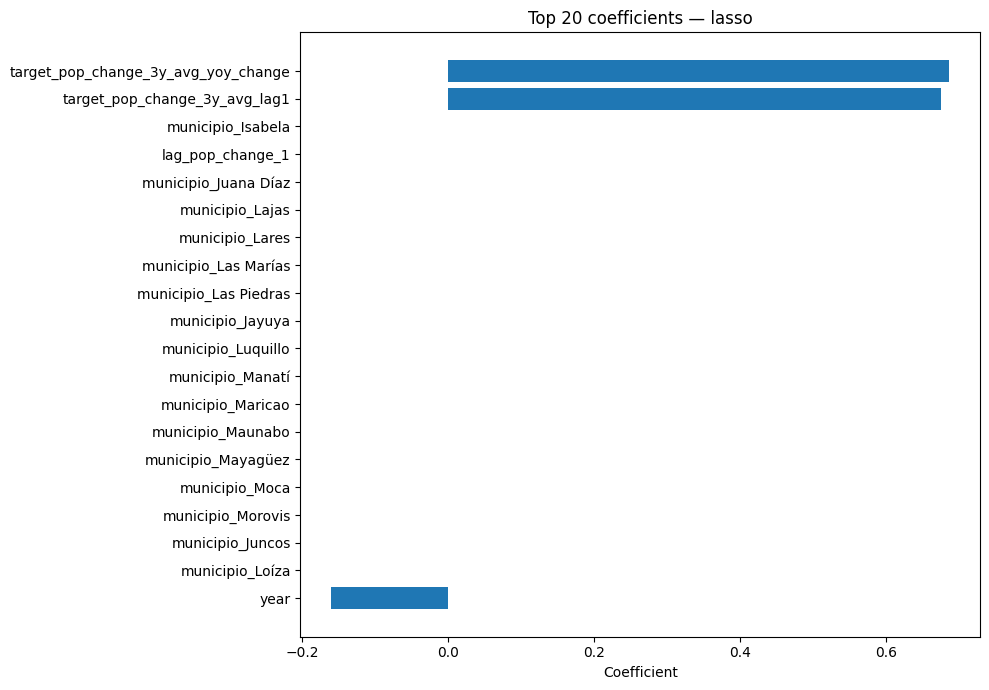

,best_model,interpretation_method,top_positive_features,top_negative_features
0,lasso,standardized_coefficients,"[target_pop_change_3y_avg_yoy_change, target_p...","[year, municipio_Peñuelas, wind_3yr_sum, seism..."


In [9]:

# =========================================================
# INTERPRET THE BEST MODEL
# - Linear models: standardized coefficient importance
# - Tree models: SHAP importance
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

if "fitted_models" not in globals() or not isinstance(fitted_models, dict):
    raise ValueError("fitted_models is not available. Run the model comparison cell first.")

best_model_name = results_df.iloc[0]["model"]
if best_model_name not in fitted_models:
    raise KeyError(f"Best model '{best_model_name}' not found in fitted_models: {list(fitted_models.keys())}")

best_pipeline = fitted_models[best_model_name]
print(f"Using fitted best model for interpretation: {best_model_name}")

if "saved_files" not in globals() or not isinstance(saved_files, list):
    saved_files = []

linear_types = (LinearRegression, Ridge, Lasso)
tree_types = (RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor)

estimator = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["pre"]

# Get transformed feature names
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    X_tmp = preprocessor.transform(X_train)
    transformed_feature_names = [f"feature_{i}" for i in range(X_tmp.shape[1])]

clean_feature_names = []
for f in transformed_feature_names:
    f = str(f).replace("num__", "").replace("cat__", "")
    f = f.replace("onehot__", "").replace("imputer__", "").replace("scaler__", "")
    clean_feature_names.append(f)

# ---------- Linear interpretation ----------
if isinstance(estimator, linear_types):
    X_train_t = preprocessor.transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    if hasattr(X_train_t, "toarray"):
        X_train_t = X_train_t.toarray()
    if hasattr(X_test_t, "toarray"):
        X_test_t = X_test_t.toarray()

    coef = np.ravel(estimator.coef_)
    coef_df = pd.DataFrame({
        "feature": clean_feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)

    coef_path = OUTPUT_DIR / "phase2_v6_best_model_coefficients.csv"
    coef_df.to_csv(coef_path, index=False)
    saved_files.append(str(coef_path))

    top_n = min(20, len(coef_df))
    plot_df = coef_df.head(top_n).sort_values("coefficient")

    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(plot_df["feature"], plot_df["coefficient"])
    plt.title(f"Top {top_n} coefficients — {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    coef_plot_path = OUTPUT_DIR / "phase2_v6_best_model_coefficients.png"
    plt.savefig(coef_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    saved_files.append(str(coef_plot_path))

    interpretation_summary = {
        "best_model": best_model_name,
        "interpretation_method": "standardized_coefficients",
        "top_positive_features": coef_df.sort_values("coefficient", ascending=False).head(10)["feature"].tolist(),
        "top_negative_features": coef_df.sort_values("coefficient", ascending=True).head(10)["feature"].tolist(),
    }

# ---------- Tree interpretation ----------
elif isinstance(estimator, tree_types):
    try:
        import shap
    except ImportError as e:
        raise ImportError(
            "The 'shap' package is required for tree-model interpretation. "
            "Install it with: python -m pip install shap"
        ) from e

    X_shap_source = X_test.copy()
    if len(X_shap_source) > 300:
        X_shap_source = X_shap_source.sample(300, random_state=42)

    X_shap = preprocessor.transform(X_shap_source)
    if hasattr(X_shap, "toarray"):
        X_shap = X_shap.toarray()
    else:
        X_shap = np.asarray(X_shap)

    explainer = shap.TreeExplainer(estimator, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_shap, check_additivity=False)

    shap_importance = pd.DataFrame({
        "feature": clean_feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    shap_csv_path = OUTPUT_DIR / "phase2_v6_best_model_shap_importance.csv"
    shap_importance.to_csv(shap_csv_path, index=False)
    saved_files.append(str(shap_csv_path))

    plt.figure()
    shap.summary_plot(
        shap_values,
        features=X_shap,
        feature_names=clean_feature_names,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    shap_plot_path = OUTPUT_DIR / "phase2_v6_best_model_shap_summary.png"
    plt.savefig(shap_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    saved_files.append(str(shap_plot_path))

    interpretation_summary = {
        "best_model": best_model_name,
        "interpretation_method": "shap_tree_explainer",
        "top_features": shap_importance.head(10)["feature"].tolist(),
    }

else:
    raise ValueError(f"Unsupported estimator type for interpretation: {type(estimator)}")

interpretation_path = OUTPUT_DIR / "phase2_v6_best_model_interpretation_summary.json"
with open(interpretation_path, "w", encoding="utf-8") as f:
    json.dump(interpretation_summary, f, indent=2)
saved_files.append(str(interpretation_path))

pd.DataFrame([interpretation_summary])


## Lead–lag analysis

This section evaluates whether key drivers matter most **contemporaneously (lag 0)** or with a **1–3 year delay**, using the **same winning model family** under the same chronological split.

The lead–lag specification should be interpreted as an **exploratory robustness check**, not as the primary forecasting model. In the current notebook, its performance is weaker than the main tuned model, so it is most useful for interpretation and hypothesis generation rather than final model selection.

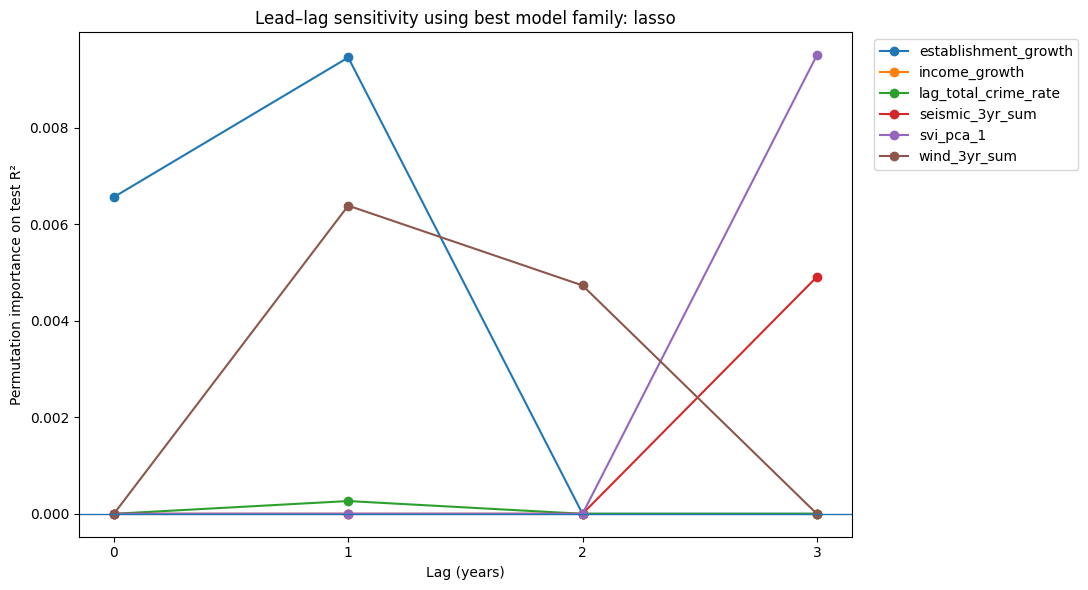

,model,val_r2,test_r2,val_rmse,test_rmse
0,lasso_leadlag,-0.214741,-0.836778,1.955389,2.038284


In [10]:

# =========================================================
# LEAD–LAG ANALYSIS (same winning model family)
# =========================================================

from sklearn.base import clone
from sklearn.inspection import permutation_importance

if "model_df" not in globals():
    raise ValueError("model_df is not defined. Run the main modeling setup cell first.")

if "target_col" not in globals() or target_col is None:
    raise ValueError("target_col is not defined. Run the main modeling setup cell first.")

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

leadlag_df = model_df.copy().sort_values(["municipio", "year"]).reset_index(drop=True)

base_driver_candidates = [
    resolved.get("wind"),
    resolved.get("seismic"),
    resolved.get("income_growth"),
    resolved.get("est_growth"),
    resolved.get("crime"),
    resolved.get("svi"),
]
base_driver_candidates = [c for c in base_driver_candidates if c is not None and c in leadlag_df.columns]

if len(base_driver_candidates) == 0:
    raise ValueError("No eligible drivers found for lead–lag analysis.")

lag_horizon = [0, 1, 2, 3]
lag_feature_cols = []
for base_col in base_driver_candidates:
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(base_col)).strip("_").lower()
    for lag in lag_horizon:
        new_col = f"{safe}_lag{lag}"
        if lag == 0:
            leadlag_df[new_col] = leadlag_df[base_col]
        else:
            leadlag_df[new_col] = leadlag_df.groupby("municipio")[base_col].shift(lag)
        lag_feature_cols.append(new_col)

context_cols = [c for c in ["lag_pop_change_1", "lag_pop_change_2", "year"] if c in leadlag_df.columns]
cat_cols_ll = [c for c in ["municipio", "region"] if c in leadlag_df.columns]

ll_feature_cols = lag_feature_cols + context_cols
ll_keep_cols = list(dict.fromkeys(ll_feature_cols + cat_cols_ll + [target_col]))
ll_model_df = leadlag_df[ll_keep_cols].copy()
ll_model_df["year"] = pd.to_numeric(ll_model_df["year"], errors="coerce")
ll_model_df = ll_model_df.dropna(subset=[target_col, "year"]).copy()

ll_train_mask = ll_model_df["year"].isin(train_years)
ll_val_mask   = ll_model_df["year"] == val_year
ll_test_mask  = ll_model_df["year"].isin(test_years)

X_ll = ll_model_df[ll_feature_cols + cat_cols_ll].copy()
y_ll = ll_model_df[target_col].copy()

X_ll_train = X_ll.loc[ll_train_mask].copy()
y_ll_train = y_ll.loc[ll_train_mask].copy()
X_ll_val   = X_ll.loc[ll_val_mask].copy()
y_ll_val   = y_ll.loc[ll_val_mask].copy()
X_ll_test  = X_ll.loc[ll_test_mask].copy()
y_ll_test  = y_ll.loc[ll_test_mask].copy()

num_cols_ll = [c for c in ll_feature_cols if c in X_ll.columns]

try:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse=False)

best_model_name = results_df.iloc[0]["model"]
best_params = best_params_by_model.get(best_model_name, {})

if best_model_name in ["ols", "ridge", "lasso"]:
    pre_ll = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols_ll),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe_ll),
            ]), cat_cols_ll),
        ],
        remainder="drop",
    )
else:
    pre_ll = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_ll),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe_ll),
            ]), cat_cols_ll),
        ],
        remainder="drop",
    )

leadlag_model = Pipeline([
    ("pre", pre_ll),
    ("model", clone(model_specs[best_model_name]["estimator"])),
])

if best_params:
    leadlag_model.set_params(**best_params)

leadlag_model.fit(X_ll_train, y_ll_train)

ll_val_pred = leadlag_model.predict(X_ll_val)
ll_test_pred = leadlag_model.predict(X_ll_test)

leadlag_summary = pd.DataFrame([{
    "model": f"{best_model_name}_leadlag",
    "val_r2": float(r2_score(y_ll_val, ll_val_pred)),
    "test_r2": float(r2_score(y_ll_test, ll_test_pred)),
    "val_rmse": float(np.sqrt(mean_squared_error(y_ll_val, ll_val_pred))),
    "test_rmse": float(np.sqrt(mean_squared_error(y_ll_test, ll_test_pred))),
}])

leadlag_summary_path = OUTPUT_DIR / "phase2_v6_leadlag_summary.csv"
leadlag_summary.to_csv(leadlag_summary_path, index=False)
saved_files.append(str(leadlag_summary_path))

perm = permutation_importance(
    leadlag_model,
    X_ll_test,
    y_ll_test,
    scoring="r2",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

leadlag_importance = pd.DataFrame({
    "feature": X_ll_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

leadlag_importance["base_driver"] = leadlag_importance["feature"].str.extract(r"^(.*)_lag[0-3]$")[0]
leadlag_importance["lag"] = leadlag_importance["feature"].str.extract(r"_lag([0-3])$")[0]
leadlag_importance = leadlag_importance.dropna(subset=["base_driver", "lag"]).copy()
leadlag_importance["lag"] = leadlag_importance["lag"].astype(int)
leadlag_importance = leadlag_importance.sort_values(["importance_mean"], ascending=False)

leadlag_imp_path = OUTPUT_DIR / "phase2_v6_leadlag_importance.csv"
leadlag_importance.to_csv(leadlag_imp_path, index=False)
saved_files.append(str(leadlag_imp_path))

plot_df = (
    leadlag_importance.groupby(["base_driver", "lag"], as_index=False)["importance_mean"]
    .mean()
    .sort_values(["base_driver", "lag"])
)

plt.figure(figsize=(11, 6))
for driver in plot_df["base_driver"].unique():
    sub = plot_df[plot_df["base_driver"] == driver]
    plt.plot(sub["lag"], sub["importance_mean"], marker="o", label=driver)

plt.axhline(0, linewidth=1)
plt.xticks([0, 1, 2, 3])
plt.xlabel("Lag (years)")
plt.ylabel("Permutation importance on test R²")
plt.title(f"Lead–lag sensitivity using best model family: {best_model_name}")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
leadlag_plot_path = OUTPUT_DIR / "phase2_v6_leadlag_importance_plot.png"
plt.savefig(leadlag_plot_path, dpi=200, bbox_inches="tight")
plt.show()
saved_files.append(str(leadlag_plot_path))

leadlag_summary


## Municipal / region / island prediction summaries

These outputs let you explain predictions at all three levels.


In [11]:

best_model_name = results_df.iloc[0]["model"]
best_preds = pred_df[pred_df["model"] == best_model_name].copy()

municipal_pred_summary = (
    best_preds.groupby(["municipio", "region"], as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
    .sort_values(["region", "municipio"])
)

region_pred_summary = (
    best_preds.groupby("region", as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
)

island_pred_summary = pd.DataFrame({
    "geography": ["Puerto Rico"],
    "actual_avg": [best_preds[target_col].mean()],
    "predicted_avg": [best_preds["prediction"].mean()],
})

saved_files.append(str(save_csv(municipal_pred_summary, "phase2_v6_municipal_prediction_summary.csv")))
saved_files.append(str(save_csv(region_pred_summary, "phase2_v6_region_prediction_summary.csv")))
saved_files.append(str(save_csv(island_pred_summary, "phase2_v6_island_prediction_summary.csv")))

display(region_pred_summary)
display(island_pred_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_municipal_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_region_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_island_prediction_summary.csv


,region,actual_avg,predicted_avg
0,Central Mountains,0.119229,-0.446559
1,East,-1.340922,-1.593491
2,Metro,-0.320350,-0.799195
3,North,-0.199783,-0.695792
4,South,-1.654667,-1.853995
5,West,-0.294296,-0.779165


,geography,actual_avg,predicted_avg
0,Puerto Rico,-0.642726,-1.049408


## Scenario forecasting

This is the closest match to your stated goal:

> If a future year has a hurricane of category # or an earthquake of magnitude x, what population change would likely be Z?

The scenario engine uses the latest available row for each geography and changes hazard variables while leaving the rest of the context intact.

These scenario outputs should be read as **directional stress tests** generated from the fitted winning model. They are useful for comparing relative sensitivity across municipalities, regions, and island-wide summaries, but they do **not** establish causal effects.

In [12]:

# Refit best tuned model on train + validation for scenario use
from sklearn.base import clone

if "model_df" not in globals():
    raise ValueError("model_df is not defined. Run the main modeling setup cell first.")

if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model comparison cell first.")

trainval_mask = outer_train_mask.copy()
X_trainval = X.loc[trainval_mask].copy()
y_trainval = y.loc[trainval_mask].copy()

best_model_key = results_df.iloc[0]["model"]
if best_model_key not in fitted_models:
    raise KeyError(f"Best model '{best_model_key}' not found in fitted_models: {list(fitted_models.keys())}")

scenario_model = clone(fitted_models[best_model_key])
scenario_model.fit(X_trainval, y_trainval)

SAFFIR_SIMPSON_TO_KNOTS = {1: 74, 2: 96, 3: 111, 4: 130, 5: 157}

def latest_geography_frame(level="municipio"):
    base = model_df.sort_values(["year"]).copy()
    numeric_cols = [c for c in feature_cols + [target_col] if c in base.columns]

    if level == "municipio":
        out = base.groupby(["municipio", "region"], as_index=False).tail(1).copy()
    elif level == "region":
        out = (
            base.groupby(["region", "year"], as_index=False)[numeric_cols]
            .mean(numeric_only=True)
        )
        out = (
            out.sort_values(["region", "year"])
            .groupby("region", as_index=False)
            .tail(1)
            .copy()
        )
        out["municipio"] = "REGION_AVG"
    elif level == "island":
        out = (
            base.groupby(["year"], as_index=False)[numeric_cols]
            .mean(numeric_only=True)
        )
        out = out.sort_values(["year"]).tail(1).copy()
        out["region"] = "Puerto Rico"
        out["municipio"] = "ISLAND_AVG"
    else:
        raise ValueError("level must be municipio, region, or island")
    return out

def _safe_name(col):
    return re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_").lower()

def apply_hurricane_scenario(frame, category=None, wind_value=None):
    out = frame.copy()
    if category is not None:
        wind_value = SAFFIR_SIMPSON_TO_KNOTS[int(category)]
    if wind_value is None:
        raise ValueError("Provide category or wind_value.")

    wind_col = resolved.get("wind")
    svi_col = resolved.get("svi")
    wind_x_svi_col = resolved.get("wind_x_svi")

    if wind_col is not None and wind_col in out.columns:
        out[wind_col] = wind_value
        safe = _safe_name(wind_col)
        for candidate in [f"{safe}_yoy_change", f"{safe}_roll3_mean"]:
            if candidate in out.columns:
                out[candidate] = wind_value

    if wind_x_svi_col is not None and svi_col is not None and svi_col in out.columns:
        out[wind_x_svi_col] = wind_value * out[svi_col]

    return out

def apply_earthquake_scenario(frame, magnitude):
    out = frame.copy()

    seismic_col = resolved.get("seismic")
    svi_col = resolved.get("svi")
    seis_x_svi_col = resolved.get("seis_x_svi")

    if seismic_col is not None and seismic_col in out.columns:
        out[seismic_col] = magnitude
        safe = _safe_name(seismic_col)
        for candidate in [f"{safe}_yoy_change", f"{safe}_roll3_mean"]:
            if candidate in out.columns:
                out[candidate] = magnitude

    if seis_x_svi_col is not None and svi_col is not None and svi_col in out.columns:
        out[seis_x_svi_col] = magnitude * out[svi_col]

    return out

def predict_frame(frame):
    pred_input = frame[[c for c in feature_cols + cat_cols if c in frame.columns]].copy()
    return scenario_model.predict(pred_input)

municipal_base = latest_geography_frame("municipio")
region_base = latest_geography_frame("region")
island_base = latest_geography_frame("island")

scenario_outputs = []

for level_name, base_frame in [("municipio", municipal_base), ("region", region_base), ("island", island_base)]:
    scenario_map = {
        "baseline": base_frame.copy(),
        "hurricane_cat3": apply_hurricane_scenario(base_frame, category=3),
        "hurricane_cat5": apply_hurricane_scenario(base_frame, category=5),
        "earthquake_m6": apply_earthquake_scenario(base_frame, magnitude=6.0),
        "earthquake_m7_5": apply_earthquake_scenario(base_frame, magnitude=7.5),
    }

    for scenario_name, frame_s in scenario_map.items():
        temp = frame_s.copy()
        temp["scenario"] = scenario_name
        temp["analysis_level"] = level_name
        temp["predicted_pop_change_3y_avg"] = predict_frame(frame_s)
        scenario_outputs.append(temp)

scenario_df = pd.concat(scenario_outputs, ignore_index=True)

scenario_csv = OUTPUT_DIR / "phase2_v6_scenario_predictions.csv"
scenario_df.to_csv(scenario_csv, index=False)
saved_files.append(str(scenario_csv))

scenario_df.head()


,year,municipio,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,median_income_nominal,median_income_real,...,lag_total_crime_rate_lag2,lag_total_crime_rate_roll3_mean,lag_total_crime_rate_yoy_change,total_population_lag1,total_population_lag2,total_population_roll3_mean,total_population_yoy_change,scenario,analysis_level,predicted_pop_change_3y_avg
0,2021.0,Vega Baja,54544.0,0.0,45974.0,184.0,24695.0,300.0,21507.0,24184.680582,...,344.756516,923.503717,-26.367132,51089.0,52192.0,52217.333333,3455.0,baseline,municipio,-0.672649
1,2021.0,Yabucoa,31047.0,0.0,26282.0,169.0,14548.0,318.0,17267.0,19416.788934,...,149.345515,313.103735,-52.642314,32867.0,33499.0,33505.000000,-1820.0,baseline,municipio,-1.864820
2,2021.0,Villalba,22341.0,0.0,18348.0,100.0,9380.0,176.0,20722.0,23301.945925,...,108.728744,209.788348,24.989437,21899.0,22403.0,22431.666667,442.0,baseline,municipio,-1.352979
3,2021.0,Vega Alta,35728.0,0.0,29794.0,101.0,16019.0,284.0,21828.0,24545.645964,...,188.209098,503.446146,-129.796048,36559.0,37106.0,37129.666667,-831.0,baseline,municipio,-0.946563
4,2021.0,Vieques,8317.0,0.0,7041.0,178.0,4967.0,156.0,14942.0,16802.320047,...,752.479763,977.404674,-155.438605,8508.0,8642.0,8640.333333,-191.0,baseline,municipio,-1.134585


In [13]:

# Human-readable scenario summaries
region_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "region"]
    .groupby(["scenario", "region"], as_index=False)["predicted_pop_change_3y_avg"]
    .mean()
)

island_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "island"]
    .groupby(["scenario"], as_index=False)["predicted_pop_change_3y_avg"]
    .mean()
)

saved_files.append(str(save_csv(region_scenario_summary, "phase2_v6_region_scenario_summary.csv")))
saved_files.append(str(save_csv(island_scenario_summary, "phase2_v6_island_scenario_summary.csv")))

display(region_scenario_summary)
display(island_scenario_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_region_scenario_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_island_scenario_summary.csv


,scenario,region,predicted_pop_change_3y_avg
0,baseline,Central Mountains,-0.709273
1,baseline,East,-0.941121
2,baseline,Metro,-1.024824
3,baseline,North,-0.714336
4,baseline,South,-1.505720
5,baseline,West,-1.018761
6,earthquake_m6,Central Mountains,-0.709273
7,earthquake_m6,East,-0.941121
8,earthquake_m6,Metro,-1.024824
9,earthquake_m6,North,-0.714336


,scenario,predicted_pop_change_3y_avg
0,baseline,-0.978832
1,earthquake_m6,-0.978832
2,earthquake_m7_5,-0.978832
3,hurricane_cat3,-0.978832
4,hurricane_cat5,-0.978832


## Interpretation guide

- **Phase 2 uses a chronological 80–20 split** so later years remain fully out-of-sample.
- **Lasso is the final selected model** in the current run because it delivered the strongest validation and test performance.
- **OLS is retained as a baseline** for comparison, but it underperformed relative to the regularized and tree-based alternatives.
- **The lead–lag model is exploratory** and weaker than the primary tuned forecasting specification.
- **Interpretability follows the winning model** rather than defaulting to a tree-based model.

Why might Lasso outperform the tree models here? First, the engineered lagged and rolling predictors appear to contain a strong structured signal that a regularized linear model can exploit efficiently. Second, the sample is moderate in size, so shrinkage helps reduce overfitting while still preserving the most informative temporal and socioeconomic features.

In [14]:

# Manifest of saved files
manifest = pd.DataFrame({"saved_file": saved_files}).drop_duplicates()
saved_files_csv = OUTPUT_DIR / "phase2_v6_saved_files_manifest.csv"
manifest.to_csv(saved_files_csv, index=False)
print("\nAll saved files:")
for p in manifest["saved_file"]:
    print(" -", p)
print("Manifest:", saved_files_csv.resolve())
manifest



All saved files:
 - phase2_outputs_v6/municipal_latest_snapshot.csv
 - phase2_outputs_v6/region_year_summary.csv
 - phase2_outputs_v6/island_year_summary.csv
 - phase2_outputs_v6/hurricane_by_svi_group_summary.csv
 - phase2_outputs_v6/earthquake_by_svi_group_summary.csv
 - phase2_outputs_v6/event_study_region_summary.csv
 - phase2_outputs_v6/phase2_v4_model_comparison.csv
 - phase2_outputs_v6/phase2_v4_predictions_long.csv
 - phase2_outputs_v6/phase2_v4_split_metadata.json
 - phase2_outputs_v6/phase2_v4_model_best_params.json
 - phase2_outputs_v6/phase2_v6_best_model_summary.json
 - phase2_outputs_v6/phase2_v6_best_model_coefficients.csv
 - phase2_outputs_v6/phase2_v6_best_model_coefficients.png
 - phase2_outputs_v6/phase2_v6_best_model_interpretation_summary.json
 - phase2_outputs_v6/phase2_v6_leadlag_summary.csv
 - phase2_outputs_v6/phase2_v6_leadlag_importance.csv
 - phase2_outputs_v6/phase2_v6_leadlag_importance_plot.png
 - phase2_outputs_v6/phase2_v6_municipal_prediction_summary.

,saved_file
0,phase2_outputs_v6/municipal_latest_snapshot.csv
1,phase2_outputs_v6/region_year_summary.csv
2,phase2_outputs_v6/island_year_summary.csv
3,phase2_outputs_v6/hurricane_by_svi_group_summa...
4,phase2_outputs_v6/earthquake_by_svi_group_summ...
5,phase2_outputs_v6/event_study_region_summary.csv
6,phase2_outputs_v6/phase2_v4_model_comparison.csv
7,phase2_outputs_v6/phase2_v4_predictions_long.csv
8,phase2_outputs_v6/phase2_v4_split_metadata.json
9,phase2_outputs_v6/phase2_v4_model_best_params....


## Conclusion

This phase focused on forecasting municipal population dynamics in Puerto Rico using a **chronological 80–20 split** that preserves temporal ordering and provides a more realistic out-of-sample evaluation.

### Model Performance

The workflow separates the data into:
- **Training years:** the earliest years in the usable target window
- **Validation year:** the final year inside the training block
- **Test years:** the latest 20% of target-eligible years

This setup reduces leakage and better reflects the real forecasting task of predicting later outcomes from earlier information.

### Final Selected Model

**Lasso is the final selected model** in this notebook. Under the chronological split, the tuned Lasso specification delivered the strongest out-of-sample performance among all tested models, outperforming OLS, Ridge, Random Forest, HistGradientBoosting, and Extra Trees.

**OLS serves as a baseline model** in this comparison. Its weaker performance is still informative because it shows that an unregularized linear specification does not generalize as well as the tuned alternatives under the current temporal design.

### Why Lasso Performed Best

Lasso likely outperformed the tree-based models for several reasons. First, the engineered lagged and rolling features appear to create a strong temporal structure that a regularized linear model can capture effectively. Second, the dataset is moderate in size, so coefficient shrinkage helps control variance and reduce overfitting. Third, Lasso simplifies the model by down-weighting or removing weaker predictors, which can improve generalization when many related municipal indicators move together.

### Key Drivers

The interpretation section reports the strongest features from the actual winning model. In this run, the most influential predictors are best understood as a combination of:
- lagged population dynamics
- rolling trend measures
- structural socioeconomic indicators
- disaster and exposure-related variables
- geography-linked differences across municipalities and regions

### Lead–Lag Findings

The lead–lag model should be interpreted as an **exploratory robustness exercise** rather than the primary forecasting specification. It is useful for testing whether certain drivers appear to matter immediately or with delay, but in this notebook it performs more weakly than the main tuned Lasso model and therefore should not be treated as the final forecasting result.

### Forecasting Insights

- Municipal forecasts remain the most variable.
- Region and island summaries are smoother and easier to interpret.
- Scenario outputs should be treated as **directional stress tests**, not causal estimates.

### Limitations

- Some important drivers are still unobserved, including policy changes, migration mechanisms, and post-disaster recovery quality.
- Municipal-level data is noisy and can limit precision.
- Scenario forecasts depend on how shocks are encoded in the engineered feature space.

### Key Takeaway

Under a chronological 80/20 split, the tuned Lasso model delivered the strongest out-of-sample performance, indicating that regularized linear structure combined with lagged and rolling municipal indicators best captured medium-term population change dynamics in Puerto Rico.

In [15]:
# Save fitted best Phase 2 pipeline for Phase 3 reuse
import joblib

best_model_key = results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_key]

joblib.dump(best_pipeline, OUTPUT_DIR / "phase2_v6_best_pipeline.joblib")
print(f"Saved fitted Phase 2 pipeline: {(OUTPUT_DIR / 'phase2_v6_best_pipeline.joblib').resolve()}")


Saved fitted Phase 2 pipeline: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis copy/phase2_outputs_v6/phase2_v6_best_pipeline.joblib
